# Off-Policy Learning in a Dynamic Treatment Regime (DTR)

This notebook demonstrates off-policy learning in a 2-stage Dynamic Treatment Regime (DTR) as described in Chapter 8 of the CRL book (Example 8.6).

In this scenario:
- A physician must decide on treatments for a patient across two stages
- S1: patient's initial condition (binary)
- X1: initial treatment choice (0 = behavioral therapy, 1 = medication)
- S2: patient's response to treatment (binary)
- X2: follow-up treatment choice (0 = continue initial, 1 = intensive combined therapy)
- Y: primary outcome (treatment success, binary)

We'll demonstrate:
1. How to evaluate policies using observational data (off-policy evaluation)
2. Two methods: Inverse Propensity Weighting (IPW) and Dynamic Programming (DP)
3. How unmeasured confounders affect the accuracy of off-policy learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import defaultdict

from causal_gym.envs import DTRExamplePCH

## 1. Generate Observational Data

First, we'll collect observational data from the behavioral policy. This is the data that would be available for off-policy learning in a real scenario.

In [2]:
def collect_observational_data(env, n_episodes=1000):
    # Collect observational data by running the behavioral policy
    data = []
    
    for _ in tqdm(range(n_episodes)):
        s1, _ = env.reset()
        
        # First stage
        x1, s2, _, _, _, info1 = env.see()
        
        # Second stage
        x2, _, y, _, _, info2 = env.see()
        
        # Record the trajectory
        data.append({
            's1': s1,
            'x1': x1,
            's2': s2,
            'x2': x2,
            'y': y
        })
    
    return pd.DataFrame(data)

In [3]:
# Create an environment with no unmeasured confounding (a1=a2=0)
env_no_conf = DTRExamplePCH(a1=0, a2=0)

# Collect observational data
obs_data = collect_observational_data(env_no_conf, n_episodes=5000)

  0%|          | 0/5000 [00:00<?, ?it/s]

In [4]:
# Display the first few rows of the observational data
obs_data.head()

,s1,x1,s2,x2,y
0,0,1,1,1,1
1,0,0,1,1,1
2,1,1,0,1,0
3,0,1,1,1,1
4,1,1,1,1,0


In [5]:
# Check the distribution of the data
print("Distribution of S1:", obs_data['s1'].value_counts(normalize=True))
print("Distribution of X1|S1=0:", obs_data[obs_data['s1'] == 0]['x1'].value_counts(normalize=True))
print("Distribution of X1|S1=1:", obs_data[obs_data['s1'] == 1]['x1'].value_counts(normalize=True))

print("Distribution of S2:", obs_data['s2'].value_counts(normalize=True))
print("Distribution of X2|S2=0:", obs_data[obs_data['s2'] == 0]['x2'].value_counts(normalize=True))
print("Distribution of X2|S2=1:", obs_data[obs_data['s2'] == 1]['x2'].value_counts(normalize=True))

print("Overall outcome distribution (Y):", obs_data['y'].value_counts(normalize=True))


Distribution of S1: s1
1    0.508
0    0.492
Name: proportion, dtype: float64
Distribution of X1|S1=0: x1
0    0.513008
1    0.486992
Name: proportion, dtype: float64
Distribution of X1|S1=1: x1
1    0.95
0    0.05
Name: proportion, dtype: float64
Distribution of S2: s2
1    0.5486
0    0.4514
Name: proportion, dtype: float64
Distribution of X2|S2=0: x2
0    0.507311
1    0.492689
Name: proportion, dtype: float64
Distribution of X2|S2=1: x2
1    0.951878
0    0.048122
Name: proportion, dtype: float64
Overall outcome distribution (Y): y
0    0.5646
1    0.4354
Name: proportion, dtype: float64


## 2. Off-Policy Evaluation Methods

We'll implement two off-policy evaluation methods from Chapter 8:

### 2.1 Inverse Propensity Weighting (IPW)

IPW uses importance sampling to reweight the observational outcomes according to the ratio of the target policy and the behavior policy probabilities. From Theorem 8.2.1 in the book:

$$
\mathbb{E}_\pi[R(Y)] = \sum_{\bar{x}_H, \bar{s}_H} \mathbb{E}[R(Y) | \bar{x}_H,\bar{s}_H] P(\bar{x}_H, \bar{s}_H) \prod_{i=1}^H \frac{\pi_i(x_i | s_i)}{P(x_i | \bar{x}_{i-1}, \bar{s}_i)}
$$

For our 2-stage DTR, this simplifies to:

$$
\mathbb{E}_\pi[Y] = \sum_{s_1, x_1, s_2, x_2} \mathbb{E}[Y | s_1, x_1, s_2, x_2] P(s_1, x_1, s_2, x_2) \frac{\\pi_1(x_1 | s_1)}{P(x_1 | s_1)} \frac{\\pi_2(x_2 | s_1, x_1, s_2)}{P(x_2 | s_1, x_1, s_2)}
$$

In [6]:
def estimate_ipw(obs_data, target_policy):
    #    Estimate the expected reward of a target policy using Inverse Propensity Weighting
    
    # Define the target policy function
    def get_target_action1(s1):
        return target_policy[0][s1]
    
    def get_target_action2(s1, x1, s2):
        return target_policy[1][s1][x1][s2]
    
    # Calculate propensity scores (behavior policy probabilities)
    # P(x1 | s1)
    propensity1 = {}
    for s1 in [0, 1]:
        s1_data = obs_data[obs_data['s1'] == s1]
        if len(s1_data) > 0:
            # Count how often x1=1 occurs when s1=s1
            propensity1[s1] = s1_data['x1'].mean()
        else:
            propensity1[s1] = 0.5  # Default if no data
    
    # P(x2 | s1, x1, s2)
    propensity2 = {}
    for s1 in [0, 1]:
        propensity2[s1] = {}
        for x1 in [0, 1]:
            propensity2[s1][x1] = {}
            for s2 in [0, 1]:
                filtered_data = obs_data[(obs_data['s1'] == s1) & 
                                        (obs_data['x1'] == x1) & 
                                        (obs_data['s2'] == s2)]
                if len(filtered_data) > 0:
                    # Count how often x2=1 occurs when (s1,x1,s2)=(s1,x1,s2)
                    propensity2[s1][x1][s2] = filtered_data['x2'].mean()
                else:
                    propensity2[s1][x1][s2] = 0.5  # Default if no data
    
    # Calculate importance weights and weighted outcomes
    weighted_outcomes = []
    
    for _, row in obs_data.iterrows():
        s1, x1, s2, x2, y = row['s1'], row['x1'], row['s2'], row['x2'], row['y']
        
        # Target policy probabilities
        target_prob1 = 1.0 if get_target_action1(s1) == x1 else 0.0
        target_prob2 = 1.0 if get_target_action2(s1, x1, s2) == x2 else 0.0
        
        # Behavior policy probabilities
        behavior_prob1 = propensity1[s1] if x1 == 1 else (1 - propensity1[s1])
        behavior_prob2 = propensity2[s1][x1][s2] if x2 == 1 else (1 - propensity2[s1][x1][s2])
        
        # Avoid division by zero
        if behavior_prob1 < 1e-10 or behavior_prob2 < 1e-10:
            continue
        
        # Importance weight
        weight = (target_prob1 / behavior_prob1) * (target_prob2 / behavior_prob2)
        
        # Weighted outcome
        weighted_outcomes.append(weight * y)
    
    # Average weighted outcomes
    if weighted_outcomes:
        return np.mean(weighted_outcomes)
    else:
        return 0.0

### 2.2 Dynamic Programming (DP)

The DP approach uses the recursive structure of the problem to estimate the expected reward. From Theorem 8.2.2 in the book:

$$
\mathbb{E}_\pi[R(Y)] = \mathbb{E}\left[\sum_{x_1} Q^{(1)}_\pi(x_1, S_1)\pi_1(x_1 | S_1)\right]
$$

where the Q-functions are defined recursively:

$$
Q^{(i)}_\pi(\bar{x}_i, \bar{s}_i) = \mathbb{E}\left[\sum_{x_{i+1}} Q^{(i+1)}_\pi(\bar{x}_{i+1}, \bar{s}_i, S_{i+1})\pi_{i+1}(x_{i+1} | S_{i+1}) \mid \bar{x}_i, \bar{s}_i\right]
$$
$$
Q^{(H)}_\pi(\bar{x}_H, \bar{s}_H) = \mathbb{E}[R(Y) | \bar{x}_H, \bar{s}_H]
$$

In [7]:
def estimate_dp(obs_data, target_policy):
    #    Estimate the expected reward of a target policy using Dynamic Programming
    
    # First, compute Q^(2) - the expected reward for each (s1,x1,s2,x2) combination
    Q2 = {}
    for s1 in [0, 1]:
        Q2[s1] = {}
        for x1 in [0, 1]:
            Q2[s1][x1] = {}
            for s2 in [0, 1]:
                Q2[s1][x1][s2] = {}
                for x2 in [0, 1]:
                    filtered_data = obs_data[(obs_data['s1'] == s1) & 
                                            (obs_data['x1'] == x1) & 
                                            (obs_data['s2'] == s2) & 
                                            (obs_data['x2'] == x2)]
                    if len(filtered_data) > 0:
                        Q2[s1][x1][s2][x2] = filtered_data['y'].mean()
                    else:
                        Q2[s1][x1][s2][x2] = 0.0  # Default if no data

    # Compute Q^(1) - the expected reward for each (s1,x1) combination
    Q1 = {}
    for s1 in [0, 1]:
        Q1[s1] = {}
        for x1 in [0, 1]:
            # Calculate P(s2 | s1, x1)
            s2_probs = {}
            filtered_data = obs_data[(obs_data['s1'] == s1) & (obs_data['x1'] == x1)]
            if len(filtered_data) > 0:
                s2_counts = filtered_data['s2'].value_counts(normalize=True)
                for s2 in [0, 1]:
                    s2_probs[s2] = s2_counts.get(s2, 0.0)
            else:
                s2_probs = {0: 0.5, 1: 0.5}  # Default if no data
            
            # Calculate Q1
            Q1[s1][x1] = 0.0
            for s2 in [0, 1]:
                x2 = target_policy[1][s1][x1][s2]  # Target policy's action at second stage
                Q1[s1][x1] += s2_probs[s2] * Q2[s1][x1][s2][x2]
    
    # Calculate expected reward under target policy
    expected_reward = 0.0
    s1_probs = obs_data['s1'].value_counts(normalize=True)
    
    for s1 in [0, 1]:
        x1 = target_policy[0][s1]  # Target policy's action at first stage
        expected_reward += s1_probs.get(s1, 0.0) * Q1[s1][x1]
    
    return expected_reward

## 3. Evaluating Different Policies

Let's evaluate different target policies using both IPW and DP methods. For comparison, we'll also directly evaluate the policies using a large number of episodes.

In [8]:
def evaluate_policy_online(env, policy, n_episodes=1000):
    #    Directly evaluate a policy by executing it in the environment
    total_reward = 0.0
    
    for _ in tqdm(range(n_episodes)):
        s1, _ = env.reset()
        
        # First stage - apply policy
        x1 = policy[0][s1]
        s2, _, _, _, info1 = env.do(x1)
        
        # Second stage - apply policy
        x2 = policy[1][s1][x1][s2]
        _, reward, _, _, info2 = env.do(x2)
        
        total_reward += reward
    
    return total_reward / n_episodes

Let's define several target policies for evaluation:

In [9]:
# Define multiple deterministic policies for testing
# Format: [pi_1, pi_2] where pi_1[s1] = x1 and pi_2[s1][x1][s2] = x2

# Policy 1: Always use behavioral therapy (X1=0), always use intensive therapy (X2=1)
policy1 = [
    {0: 0, 1: 0},  # Stage 1: π₁(s₁) → x₁
    {  # Stage 2: π₂(s₁, x₁, s₂) → x₂
        0: {0: {0: 1, 1: 1}, 1: {0: 1, 1: 1}},
        1: {0: {0: 1, 1: 1}, 1: {0: 1, 1: 1}}
    }
]

# Policy 2: Always use medication (X1=1), always continue (X2=0)
policy2 = [
    {0: 1, 1: 1},  # Stage 1
    {  # Stage 2
        0: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
        1: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}}
    }
]

# Policy 3: Treatment depends on initial condition (X1=S1), 
# follow-up depends on response (X2=S2)
policy3 = [
    {0: 0, 1: 1},  # Stage 1: match treatment to condition
    {  # Stage 2: match follow-up to response
        0: {0: {0: 0, 1: 1}, 1: {0: 0, 1: 1}},
        1: {0: {0: 0, 1: 1}, 1: {0: 0, 1: 1}}
    }
]

# Policy 4: The optimal policy from Example 8.6
# X1=0 (behavioral therapy), X2=1 (intensive therapy)
policy4 = [
    {0: 0, 1: 0},  # Stage 1: always behavioral therapy
    {  # Stage 2: always intensive therapy
        0: {0: {0: 1, 1: 1}, 1: {0: 1, 1: 1}},
        1: {0: {0: 1, 1: 1}, 1: {0: 1, 1: 1}}
    }
]

## 4. Evaluation with No Unmeasured Confounders

We'll first evaluate the policies in a setting where the No Unmeasured Confounders (NUC) assumption holds (a1=a2=0
   

In [10]:
# Evaluate policies with no unmeasured confounding
results_no_conf = []

for policy_idx, policy in enumerate([policy1, policy2, policy3, policy4], 1):
    # Evaluate using offline methods (IPW and DP)
    ipw_estimate = estimate_ipw(obs_data, policy)
    dp_estimate = estimate_dp(obs_data, policy)
    
    # Evaluate using online execution for ground truth
    online_estimate = evaluate_policy_online(env_no_conf, policy, n_episodes=1000)
    
    results_no_conf.append({
        'Policy': f'Policy {policy_idx}',
        'IPW Estimate': ipw_estimate,
        'DP Estimate': dp_estimate,
        'True Value': online_estimate,
        'IPW Error': abs(ipw_estimate - online_estimate),
        'DP Error': abs(dp_estimate - online_estimate)
    })

# Display results
pd.DataFrame(results_no_conf)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

,Policy,IPW Estimate,DP Estimate,True Value,IPW Error,DP Error
0,Policy 1,0.720,0.720,0.725,0.005,0.005
1,Policy 2,0.000,0.000,0.000,0.000,0.000
2,Policy 3,0.492,0.492,0.484,0.008,0.008
3,Policy 4,0.720,0.720,0.734,0.014,0.014


Let's visualize the comparison of estimations:

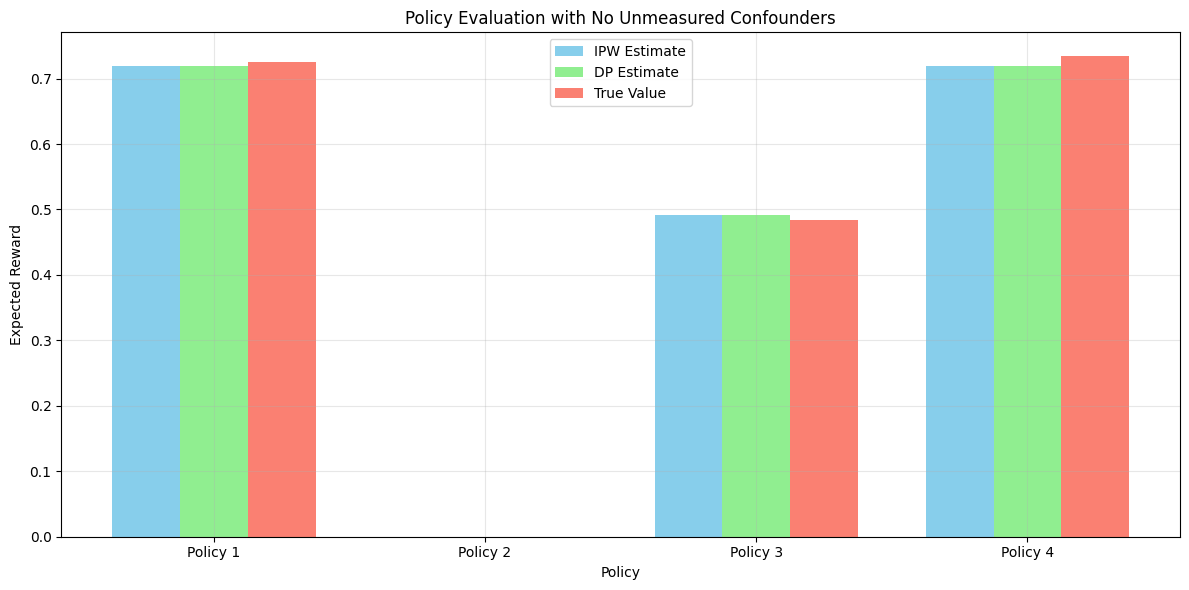

In [11]:
# Create a bar chart comparing the estimates
df_no_conf = pd.DataFrame(results_no_conf)

plt.figure(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(df_no_conf))

plt.bar(x - bar_width, df_no_conf['IPW Estimate'], width=bar_width, label='IPW Estimate', color='skyblue')
plt.bar(x, df_no_conf['DP Estimate'], width=bar_width, label='DP Estimate', color='lightgreen')
plt.bar(x + bar_width, df_no_conf['True Value'], width=bar_width, label='True Value', color='salmon')

plt.xlabel('Policy')
plt.ylabel('Expected Reward')
plt.title('Policy Evaluation with No Unmeasured Confounders')
plt.xticks(x, df_no_conf['Policy'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluation with Unmeasured Confounders

Now, let's see what happens when there are unmeasured confounders (a1, a2 > 0). In this case, the NUC assumption is violated, and we expect the offline methods to provide inaccurate estimates.

In [12]:
# Create an environment with unmeasured confounding
env_conf = DTRExamplePCH(a1=3, a2=3)

# Collect observational data with confounding
obs_data_conf = collect_observational_data(env_conf, n_episodes=5000)

  0%|          | 0/5000 [00:00<?, ?it/s]

In [13]:
# Evaluate policies with unmeasured confounding
results_conf = []

for policy_idx, policy in enumerate([policy1, policy2, policy3, policy4], 1):
    # Evaluate using offline methods (IPW and DP)
    ipw_estimate = estimate_ipw(obs_data_conf, policy)
    dp_estimate = estimate_dp(obs_data_conf, policy)
    
    # Evaluate using online execution for ground truth
    online_estimate = evaluate_policy_online(env_conf, policy, n_episodes=1000)
    
    results_conf.append({
        'Policy': f'Policy {policy_idx}',
        'IPW Estimate': ipw_estimate,
        'DP Estimate': dp_estimate,
        'True Value': online_estimate,
        'IPW Error': abs(ipw_estimate - online_estimate),
        'DP Error': abs(dp_estimate - online_estimate)
    })

# Display results
pd.DataFrame(results_conf)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

,Policy,IPW Estimate,DP Estimate,True Value,IPW Error,DP Error
0,Policy 1,0.70456,0.70456,0.728,0.02344,0.02344
1,Policy 2,0.00000,0.00000,0.000,0.00000,0.00000
2,Policy 3,0.50760,0.50760,0.496,0.01160,0.01160
3,Policy 4,0.70456,0.70456,0.741,0.03644,0.03644


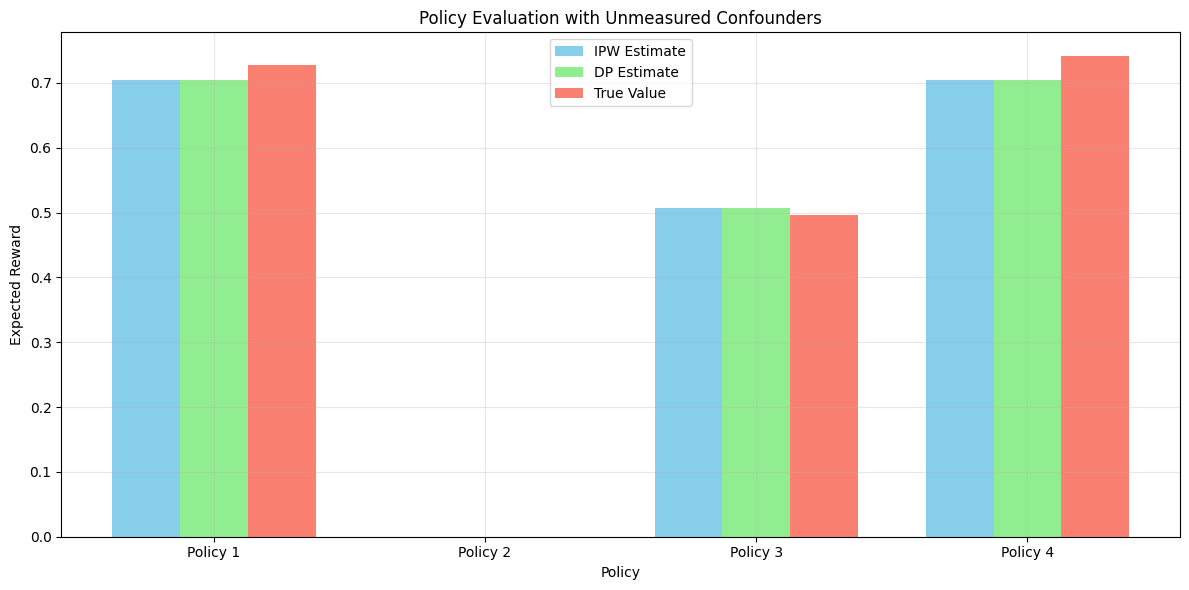

In [14]:
# Create a bar chart comparing the estimates
df_conf = pd.DataFrame(results_conf)

plt.figure(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(df_conf))

plt.bar(x - bar_width, df_conf['IPW Estimate'], width=bar_width, label='IPW Estimate', color='skyblue')
plt.bar(x, df_conf['DP Estimate'], width=bar_width, label='DP Estimate', color='lightgreen')
plt.bar(x + bar_width, df_conf['True Value'], width=bar_width, label='True Value', color='salmon')

plt.xlabel('Policy')
plt.ylabel('Expected Reward')
plt.title('Policy Evaluation with Unmeasured Confounders')
plt.xticks(x, df_conf['Policy'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()